# Random Forest Models

Here we train Random Forest models for all three binary classification tasks:
- Healthy vs infected
- Symptomatic non-COVID vs COVID
- Severe vs non-severe COVID


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/UCSD_class/cse291-project

/content/drive/MyDrive/UCSD_class/cse291-project


## 1. Load libraries and task folders

Read the task-specific train/test matrices, labels, metadata, and selected peptide feature lists created in `preprocessing.ipynb`.


In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)

In [10]:
# Same process as in the Logistic Regression baseline model

PROCESSED_DIR = Path("data/processed")
TASK_NAMES = [
    "healthy_vs_infected",
    "symptomatic_non_covid_vs_covid",
    "severe_vs_nonsevere",
]

task_data = {}

for task_name in TASK_NAMES:
    task_dir = PROCESSED_DIR / task_name
    task_data[task_name] = {
        "dir": task_dir,
        "X_train": pd.read_csv(task_dir / "X_train_scaled.csv", index_col=0),
        "X_test": pd.read_csv(task_dir / "X_test_scaled.csv", index_col=0),
        "y_train": pd.read_csv(task_dir / "y_train.csv", index_col=0).squeeze("columns"),
        "y_test": pd.read_csv(task_dir / "y_test.csv", index_col=0).squeeze("columns"),
        "metadata_train": pd.read_csv(task_dir / "metadata_train.csv", index_col=0),
        "metadata_test": pd.read_csv(task_dir / "metadata_test.csv", index_col=0),
        "selected_peptides": pd.read_csv(task_dir / "selected_peptides.csv"),
    }

    print(f"\n{task_name}")
    print(f"X_train shape: {task_data[task_name]['X_train'].shape}")
    print(f"X_test shape: {task_data[task_name]['X_test'].shape}")
    print("Train label counts:")
    print(task_data[task_name]["metadata_train"]["label_name"].value_counts())
    print("Test label counts:")
    print(task_data[task_name]["metadata_test"]["label_name"].value_counts())



healthy_vs_infected
X_train shape: (72, 35882)
X_test shape: (18, 35882)
Train label counts:
label_name
Infected    54
Healthy     18
Name: count, dtype: int64
Test label counts:
label_name
Infected    14
Healthy      4
Name: count, dtype: int64

symptomatic_non_covid_vs_covid
X_train shape: (54, 35882)
X_test shape: (14, 35882)
Train label counts:
label_name
COVID-19                    34
Symptomatic-non-COVID-19    20
Name: count, dtype: int64
Test label counts:
label_name
COVID-19                    9
Symptomatic-non-COVID-19    5
Name: count, dtype: int64

severe_vs_nonsevere
X_train shape: (34, 35882)
X_test shape: (9, 35882)
Train label counts:
label_name
Non-severe-COVID-19    20
Severe-COVID-19        14
Name: count, dtype: int64
Test label counts:
label_name
Non-severe-COVID-19    5
Severe-COVID-19        4
Name: count, dtype: int64


## 2. Nested CV helpers

We use 5-fold nested cross-validation:
- **Outer loop (5-fold)**: each fold holds out ~18 samples as the test set. The outer CV
  score is an unbiased estimate of generalisation performance because hyperparameter
  selection never sees the outer test fold.
- **Inner loop (4-fold)**: within each outer training split, `GridSearchCV` is used to tune hyperparameters and selects the best `(loss, C)` pair using 4-fold CV on the inner training data.


After nested CV, we refit the best configuration and evaluate the final fitted model on the held-out test set.


In [ ]:
TOP_K_FEATURES = 5000

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

PARAM_GRID = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [3, 5, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_features": ["sqrt", "log2"],
}

def make_rf_pipeline(n_features=None):
    k = min(TOP_K_FEATURES, n_features) if n_features else TOP_K_FEATURES

    rf = RandomForestClassifier(
        class_weight="balanced",
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
    )

    return Pipeline([
        ("model", rf),
    ])


def safe_metric(fn, y_true, y_score, **kwargs):
    try:
        return fn(y_true, y_score, **kwargs)
    except Exception:
        return np.nan


def run_nested_cv(task_name, data):
    X_train = data["X_train"]
    y_train = data["y_train"]
    n_features = X_train.shape[1]

    outer_scores = []
    best_params_per_fold = []

    for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_outer_train = X_train.iloc[train_idx]
        X_outer_val = X_train.iloc[val_idx]
        y_outer_train = y_train.iloc[train_idx]
        y_outer_val = y_train.iloc[val_idx]

        base_pipeline = make_rf_pipeline(n_features=n_features)

        grid_search = GridSearchCV(
            estimator=base_pipeline,
            param_grid=PARAM_GRID,
            cv=inner_cv,
            scoring="balanced_accuracy",
            n_jobs=-1,
            error_score=np.nan,
            # verbose = 1,
        )

        grid_search.fit(X_outer_train, y_outer_train)

        best_pipeline = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_params_per_fold.append(best_params)

        y_pred = best_pipeline.predict(X_outer_val)
        y_proba = best_pipeline.predict_proba(X_outer_val)[:, 1]

        outer_scores.append({
            "fold": fold_idx,
            "best_n_estimators": best_params["model__n_estimators"],
            "best_max_depth": best_params["model__max_depth"],
            "best_min_samples_split": best_params["model__min_samples_split"],
            "best_min_samples_leaf": best_params["model__min_samples_leaf"],
            "best_max_features": best_params["model__max_features"],
            "val_accuracy": accuracy_score(y_outer_val, y_pred),
            "val_balanced_accuracy": balanced_accuracy_score(y_outer_val, y_pred),
            "val_f1": f1_score(y_outer_val, y_pred, zero_division=0),
            "val_roc_auc": safe_metric(roc_auc_score, y_outer_val, y_proba),
            "val_auprc": safe_metric(average_precision_score, y_outer_val, y_proba),
        })

        print(
            f"Fold {fold_idx}: "
            f"depth={best_params['model__max_depth']}, "
            f"leaf={best_params['model__min_samples_leaf']}, "
            f"features={best_params['model__max_features']} | "
            f"bal_acc={outer_scores[-1]['val_balanced_accuracy']:.3f}, "
            f"AUPRC={outer_scores[-1]['val_auprc']:.3f}"
        )

    return outer_scores, best_params_per_fold

## 3. Run nested CV for all tasks

We use nested CV for unbiased performance estimation. This helps us to answer the question of whether this modelling approach is trustworthy.

In [ ]:
nested_cv_results = {}
nested_cv_best_params = {}

for task_name, data in task_data.items():
    print(f"\n{'='*60}")
    print(f"Running {task_name}...")
    fold_scores, fold_params = run_nested_cv(task_name, data)
    nested_cv_results[task_name] = fold_scores
    nested_cv_best_params[task_name] = fold_params

"""Calculate the aggregate the per-fold outer scores. The nested CV mean averaged
across 5 outer folds covers all ~90 samples and is therefore less susceptible to noise
than the refitted final model's test-set score (a single evaluation on ~18 samples)."""

aggregate_cv_results = {}

for task_name, fold_scores in nested_cv_results.items():
    aggregate_cv_results[task_name] = {
        "accuracy_mean": np.mean([r["val_accuracy"] for r in fold_scores]),
        "balanced_accuracy_mean": np.mean([r["val_balanced_accuracy"] for r in fold_scores]),
        "f1_mean": np.mean([r["val_f1"] for r in fold_scores]),
        "roc_auc_mean": np.mean([r["val_roc_auc"] for r in fold_scores]),
        "auprc_mean": np.mean([r["val_auprc"] for r in fold_scores]),
    }



Running healthy_vs_infected...


KeyError: 'model__min_samples_split'

In [10]:
pd.DataFrame(aggregate_cv_results).T

,accuracy_mean,balanced_accuracy_mean,f1_mean,roc_auc_mean,auprc_mean
healthy_vs_infected,0.779048,0.850000,0.812865,0.914545,0.971106
symptomatic_non_covid_vs_covid,0.794545,0.825000,0.791429,0.866667,0.932830
severe_vs_nonsevere,0.761905,0.791667,0.766667,0.741667,0.720000


## 4. Select best configuration and fit final model

The nested CV gives us an unbiased performance estimate, but for deployment and coefficient inspection we need a single final model per task. We run one more inner-loop grid search on the full training set to select the best `(loss, C)`, then refit.


In [12]:
final_results = []
final_pipelines = {}

for task_name, data in task_data.items():
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    n_features = X_train.shape[1]

    base_pipeline = make_rf_pipeline(n_features=n_features)
    final_grid = GridSearchCV(
        estimator=base_pipeline,
        param_grid=PARAM_GRID,
        cv=inner_cv,
        scoring="balanced_accuracy",
        n_jobs=-1,
        error_score=np.nan,
        # verbose = 1,
    )

    final_grid.fit(X_train, y_train)

    best_pipeline = final_grid.best_estimator_
    best_params = final_grid.best_params_

    print(f"\n{task_name}: best config")
    print(best_params)

    y_pred = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]

    final_results.append({
        "task": task_name,
        "best_n_estimators": best_params["model__n_estimators"],
        "best_max_depth": best_params["model__max_depth"],
        "best_min_samples_split": best_params["model__min_samples_split"],
        "best_min_samples_leaf": best_params["model__min_samples_leaf"],
        "best_max_features": best_params["model__max_features"],
        "top_k_features": min(TOP_K_FEATURES, n_features),
        "train_samples": X_train.shape[0],
        "test_samples": X_test.shape[0],

        "cv_accuracy_mean": aggregate_cv_results[task_name]["accuracy_mean"],
        "cv_balanced_accuracy_mean": aggregate_cv_results[task_name]["balanced_accuracy_mean"],
        "cv_f1_mean": aggregate_cv_results[task_name]["f1_mean"],
        "cv_roc_auc_mean": aggregate_cv_results[task_name]["roc_auc_mean"],
        "cv_auprc_mean": aggregate_cv_results[task_name]["auprc_mean"],

        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0),
        "test_roc_auc": safe_metric(roc_auc_score, y_test, y_proba),
        "test_auprc": safe_metric(average_precision_score, y_test, y_proba),
    })

    final_pipelines[task_name] = best_pipeline

results_df = pd.DataFrame(final_results).sort_values("task").reset_index(drop=True)
results_df


healthy_vs_infected: best config
{'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__min_samples_split': 2, 'model__n_estimators': 200}

symptomatic_non_covid_vs_covid: best config
{'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}

severe_vs_nonsevere: best config
{'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}


,task,best_n_estimators,best_max_depth,best_min_samples_split,best_min_samples_leaf,best_max_features,top_k_features,train_samples,test_samples,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,cv_auprc_mean,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_auprc
0,healthy_vs_infected,200,3,2,3,sqrt,1000,72,18,0.793333,0.623485,0.873739,0.884697,0.963070,1.000000,1.00,1.0,1.0,1.000000,1.0,1.000000
1,severe_vs_nonsevere,200,3,2,5,sqrt,1000,34,9,0.614286,0.608333,0.536667,0.716667,0.730794,0.444444,0.45,0.4,0.5,0.444444,0.7,0.767857
2,symptomatic_non_covid_vs_covid,200,3,2,5,sqrt,1000,54,14,0.796364,0.746429,0.857417,0.815476,0.904871,1.000000,1.00,1.0,1.0,1.000000,1.0,1.000000


# 5. Save results and per-task plots

Saved combined results table to: /content/drive/MyDrive/UCSD_class/cse291-project/data/processed/random_forest_results_all_tasks.csv


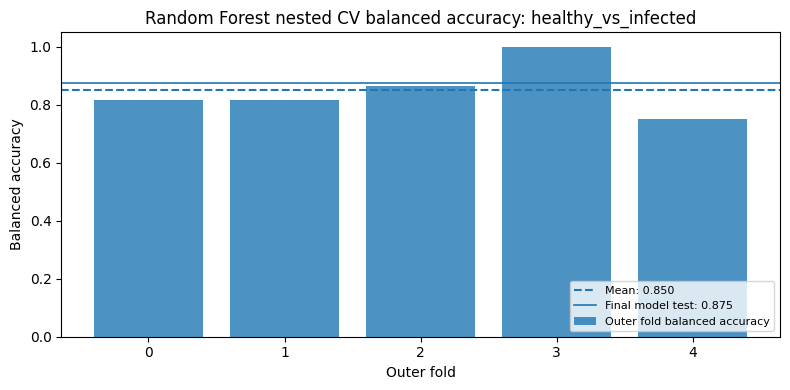

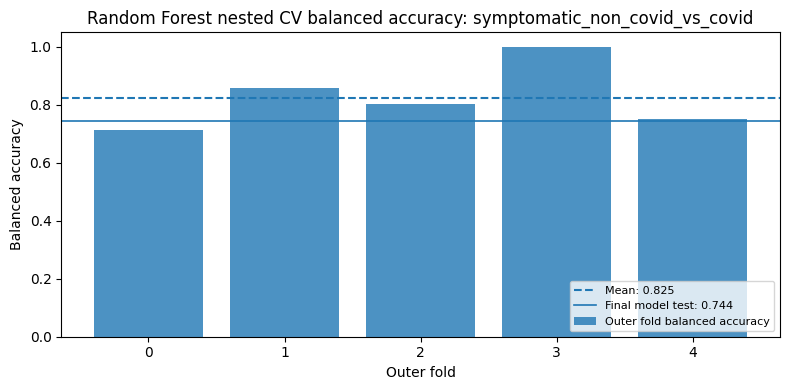

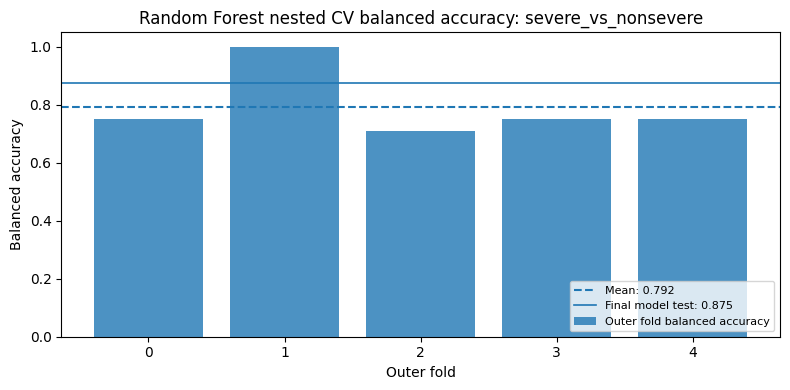

In [11]:
results_path = PROCESSED_DIR / "random_forest_results_all_tasks.csv"
results_df.to_csv(results_path, index=False)
print(f"Saved combined results table to: {results_path.resolve()}")

for task_name, data in task_data.items():
    task_dir = data["dir"]
    row = results_df[results_df["task"] == task_name].iloc[0]
    fold_df = pd.DataFrame(nested_cv_results[task_name])

    # Save per-task CSVs
    pd.DataFrame([row]).to_csv(task_dir / "random_forest_final_results.csv", index=False)
    fold_df.to_csv(task_dir / "random_forest_nested_cv_folds.csv", index=False)

    # Plot nested CV balanced accuracy
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(
        fold_df["fold"],
        fold_df["val_balanced_accuracy"],
        alpha=0.8,
        label="Outer fold balanced accuracy",
    )

    ax.axhline(
        fold_df["val_balanced_accuracy"].mean(),
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {fold_df['val_balanced_accuracy'].mean():.3f}",
    )

    ax.axhline(
        row["test_balanced_accuracy"],
        linestyle="-",
        linewidth=1.2,
        label=f"Final model test: {row['test_balanced_accuracy']:.3f}",
    )

    ax.set_xlabel("Outer fold")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(fold_df["fold"])
    ax.set_title(f"Random Forest nested CV balanced accuracy: {task_name}")
    ax.legend(fontsize=8, loc="lower right")

    plt.tight_layout()
    fig.savefig(
        task_dir / "random_forest_nested_cv_balanced_accuracy.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="white",
    )
    plt.show()

# 6. Inspect best coefficients for each task

Extract the peptide features with the largest absolute coefficients from the inner LinearSVC pipeline. These are the SVM decision-boundary weights and correspond directly to peptide importance.

In [ ]:
importance_tables = {}

for task_name, data in task_data.items():
    pipeline = final_pipelines[task_name]

    selector = pipeline.named_steps["select"]
    rf_model = pipeline.named_steps["model"]

    selected_feature_names = data["X_train"].columns[selector.get_support()]
    importances = rf_model.feature_importances_

    importance_df = pd.DataFrame({
        "task": task_name,
        "peptide": selected_feature_names,
        "importance": importances,
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False,
    ).reset_index(drop=True)

    importance_tables[task_name] = importance_df

    task_dir = data["dir"]
    importance_df.to_csv(task_dir / "random_forest_feature_importance.csv", index=False)

    top_plot_df = importance_df.head(20).sort_values("importance")

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top_plot_df["peptide"], top_plot_df["importance"], alpha=0.85)

    ax.set_xlabel("Random Forest feature importance")
    ax.set_ylabel("Peptide")
    ax.set_title(f"Top peptide importances: {task_name}")
    ax.tick_params(axis="y", labelsize=7)

    plt.tight_layout()
    fig.savefig(
        task_dir / "random_forest_feature_importance.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
        edgecolor="white",
    )
    plt.show()


print("Top 5 peptides per task:")
for task_name, importance_df in importance_tables.items():
    print(f"\n{task_name}")
    print(importance_df[["peptide", "importance"]].head(5).to_string(index=False))